In [1]:
using Oceananigans
using CairoMakie
using CairoMakie.Colors
using Statistics

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

include("../src-fig/plotting.jl")
include("../src-fig/video/full_video.jl")
include("front.jl")

[ Info: Oceananigans will use 4 threads


front_width (generic function with 1 method)

In [2]:
function buoyancy_video(DFM, filename)
    n = Observable(800)
    fig = Figure(; size=(800, 600), fontsize=18)

    ∫αdt = normalized_time(DFM)
    iterations, times = iterations_times(DFM)
    sp = simulation_parameters(DFM)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
    b_center = avg_buoyancy(DFM, -0.9sp.H, -0.1sp.H)
    b_surface = avg_buoyancy(DFM, -15, -10)
    db = -sp.Δb / 6
    η, η_k = mixed_layer_height(DFM, b_surface, db)
    C = @sprintf "%02.1f" :C in keys(sp) ? sp.C : sp.Ek
    
    title = @lift let
        t_val = @sprintf "%03.1f" sp.f * times[$n] / 2π
        hr_val = @sprintf "%03.0f" times[$n] / 3600
        s_val = @sprintf "%03.2f" ∫αdt[$n]
        L"C = %$C \quad ft / 2\pi = %$(t_val) \quad s = %$(s_val) \quad t = %$(hr_val)~\text{hr} "
    end
    
    ax_x = Axis(fig[1, 1];
        xlabel = L"x / \text{km}",
        ylabel = L"z / \text{m}",
        limits = (-sp.Lx / 2000, sp.Lx / 2000, -sp.Lz, 0),
        title,
        xticks = [-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5]
    )
    
    ax_h = Axis(fig[2, 1];
        xlabel = L"x / \text{km}",
        ylabel = L"z / \text{m}",
        limits = (-sp.Lh / 2000, sp.Lh / 2000, -sp.Lz, 0),
        xticks = [-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5]
    )
    hidexdecorations!(ax_x; ticks=false)
    
    b = @lift (get_field(DFM, "b_dfm", iterations[$n]) .- mean(b_center[$n, :])) ./ sp.Δb
    mld = @lift η[$n, :]
    
    levels = (-0.5):(1 / 6):(0.5)
    colormap = reverse(to_colormap(:deep))
    
    bl = -1 / 3
    br = 1 / 3
    ctfs = map([ax_x, ax_h]) do ax
        ctf = contourf!(ax, xsᶜ ./ 1000, zsᶜ, b; 
            colormap,
            levels,
            extendlow=:white
        )
        contour!(ax, xsᶜ ./ 1000, zsᶜ, b; 
            color = :red,
            levels = [bl]
        )
        contour!(ax, xsᶜ ./ 1000, zsᶜ, b; 
            color = :red,
            levels = [br]
        )
        
        #lines!(ax, xsᶜ ./ 1000, mld;
        #    color = :blue
        #)
    
        lines!(ax, xsᶜ ./ 1000, x->-0.1sp.H;
            color = (:black, 0.3)
        )
        lines!(ax, xsᶜ ./ 1000, x->-0.9sp.H;
            color = (:black, 0.3)
        )
        ctf
    end
    
    #subfig_label!(fig[1, 1], 1; fontsize=18)
    #subfig_label!(fig[2, 1], 2; fontsize=18)
    Colorbar(fig[1:2, 2], ctfs[1]; label=L"b / \Delta b")
    N = length(iterations)
    return fig
    println()
    record(fig, filename, 1:N; framerate=24) do i
        print("\r$i / $N")
        n[] = i
    end
    println()
    
    fig
end

buoyancy_video (generic function with 1 method)

In [4]:
Cs = ["1_0", "1_4", "1_8", "2_0", "2_6", "3_0"]
Cs = Cs[1:2]
αs = ["0_10", "0_05"]
run_ids = ["a$α-b1_0-C$C" for C in Cs, α in αs][:]
foldernames = [joinpath("../../scratch/turbulence-at-many-fronts", run_id) for run_id in run_ids]

buoyancy_video(joinpath(foldernames[4], "DFM.jld2"), "buoyancy-$(run_ids[4]).mp4")

LoadError: KeyError: key "timeseries/b_coarse" not found

In [ ]:
#buoyancy_video("../../scratch/turbulence-at-many-fronts/StrainM-Ek07/DFM.jld2", "buoyancy-StrainM-C07.mp4")
#buoyancy_video("../../scratch/turbulence-at-many-fronts/StrainM-Ek10/DFM.jld2", "buoyancy-StrainM-C10.mp4")
#fig = buoyancy_video("../../scratch/turbulence-at-many-fronts/StrainM-C14/DFM.jld2", "buoyancy-StrainM-C14.mp4")
#save("buoyancy-StrainM-C14", fig; px_per_unit=2)

for C in ["20", "17-GRL"]
    fig = buoyancy_video("../../scratch/turbulence-at-many-fronts/StrainM-C$(C)/DFM.jld2", "buoyancy-StrainM-C$(C).mp4")
    save("buoyancy-StrainM-C$(C)-noml.png", fig; px_per_unit=2)
end
#buoyancy_video("../../scratch/turbulence-at-many-fronts/StrainM-Ek20/DFM.jld2", "buoyancy-StrainM-C20.mp4")


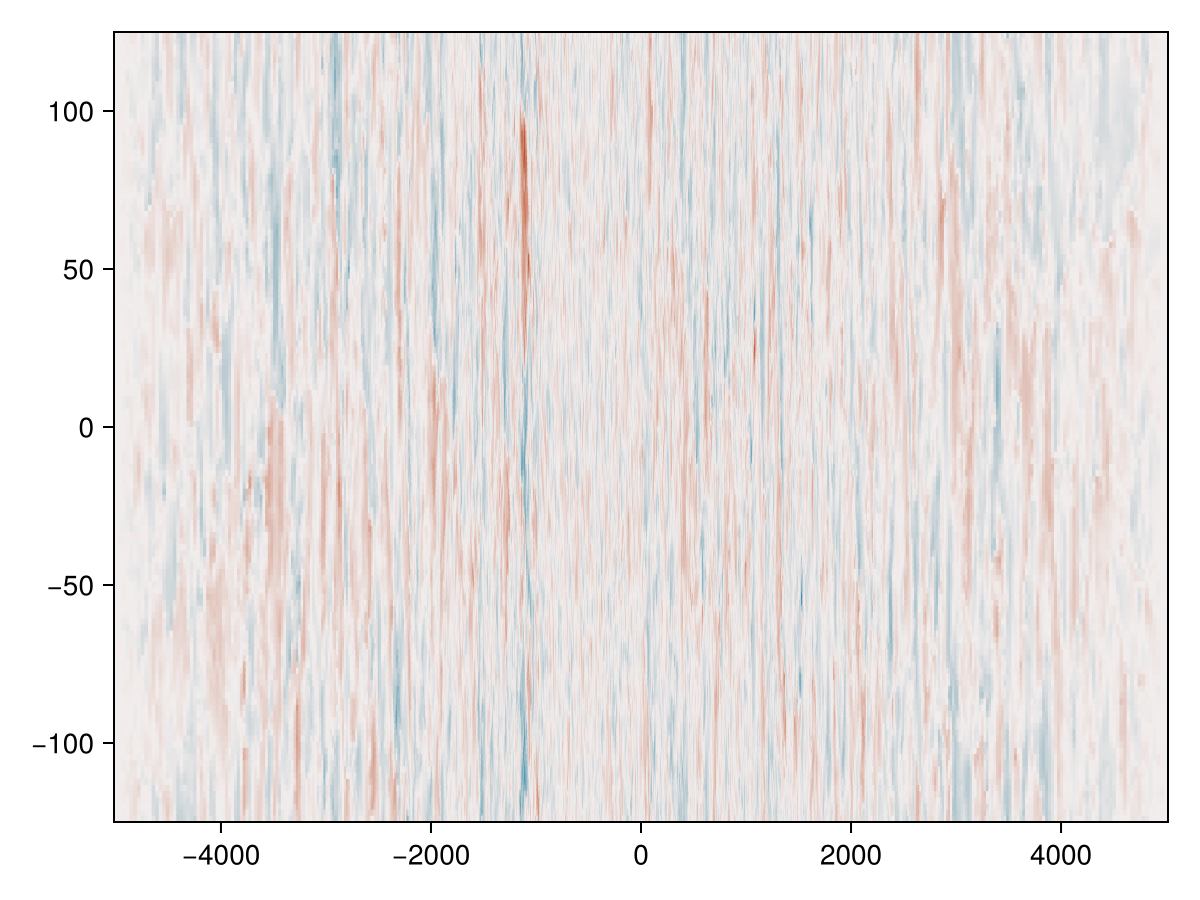

In [18]:
DFM = "../../scratch/turbulence-at-many-fronts/StrainM-C17-GRL/DFM.jld2"
SLICES = "../../scratch/turbulence-at-many-fronts/StrainM-C17-GRL/SLICES.jld2"

iterations, times = iterations_times(DFM)
sp = simulation_parameters(DFM)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)

field = get_field(SLICES, "z005_u", iterations[end])
heatmap(xsᶠ, ysᶜ, field .- mean(field; dims=2); colormap=:balance, colorrange=(-0.1, 0.1))